In [2]:
import numpy as np
import matplotlib.pyplot as plt
import os
from posydon.popsyn.synthetic_population import Rates
from posydon.popsyn.rate_calculation import get_shell_comoving_volume

mass_bins = np.linspace(10, 200, 51)
q_bins = np.linspace(0, 1, 51)
chi_bins = np.linspace(-0.2, 1, 51)

# Intrinsic Population

Processing folder: Eddington-limited
Missing ini parameter: metallicity
Missing ini parameter: orbital_separation_scheme
Missing ini parameter: orbital_separation_min
Missing ini parameter: orbital_separation_max
Rates data loaded.
Processing folder: GRMHD
Missing ini parameter: metallicity
Missing ini parameter: orbital_separation_scheme
Missing ini parameter: orbital_separation_min
Missing ini parameter: orbital_separation_max
Rates data loaded.
Processing folder: conservative
Missing ini parameter: metallicity
Missing ini parameter: orbital_separation_scheme
Missing ini parameter: orbital_separation_min
Missing ini parameter: orbital_separation_max
Rates data loaded.


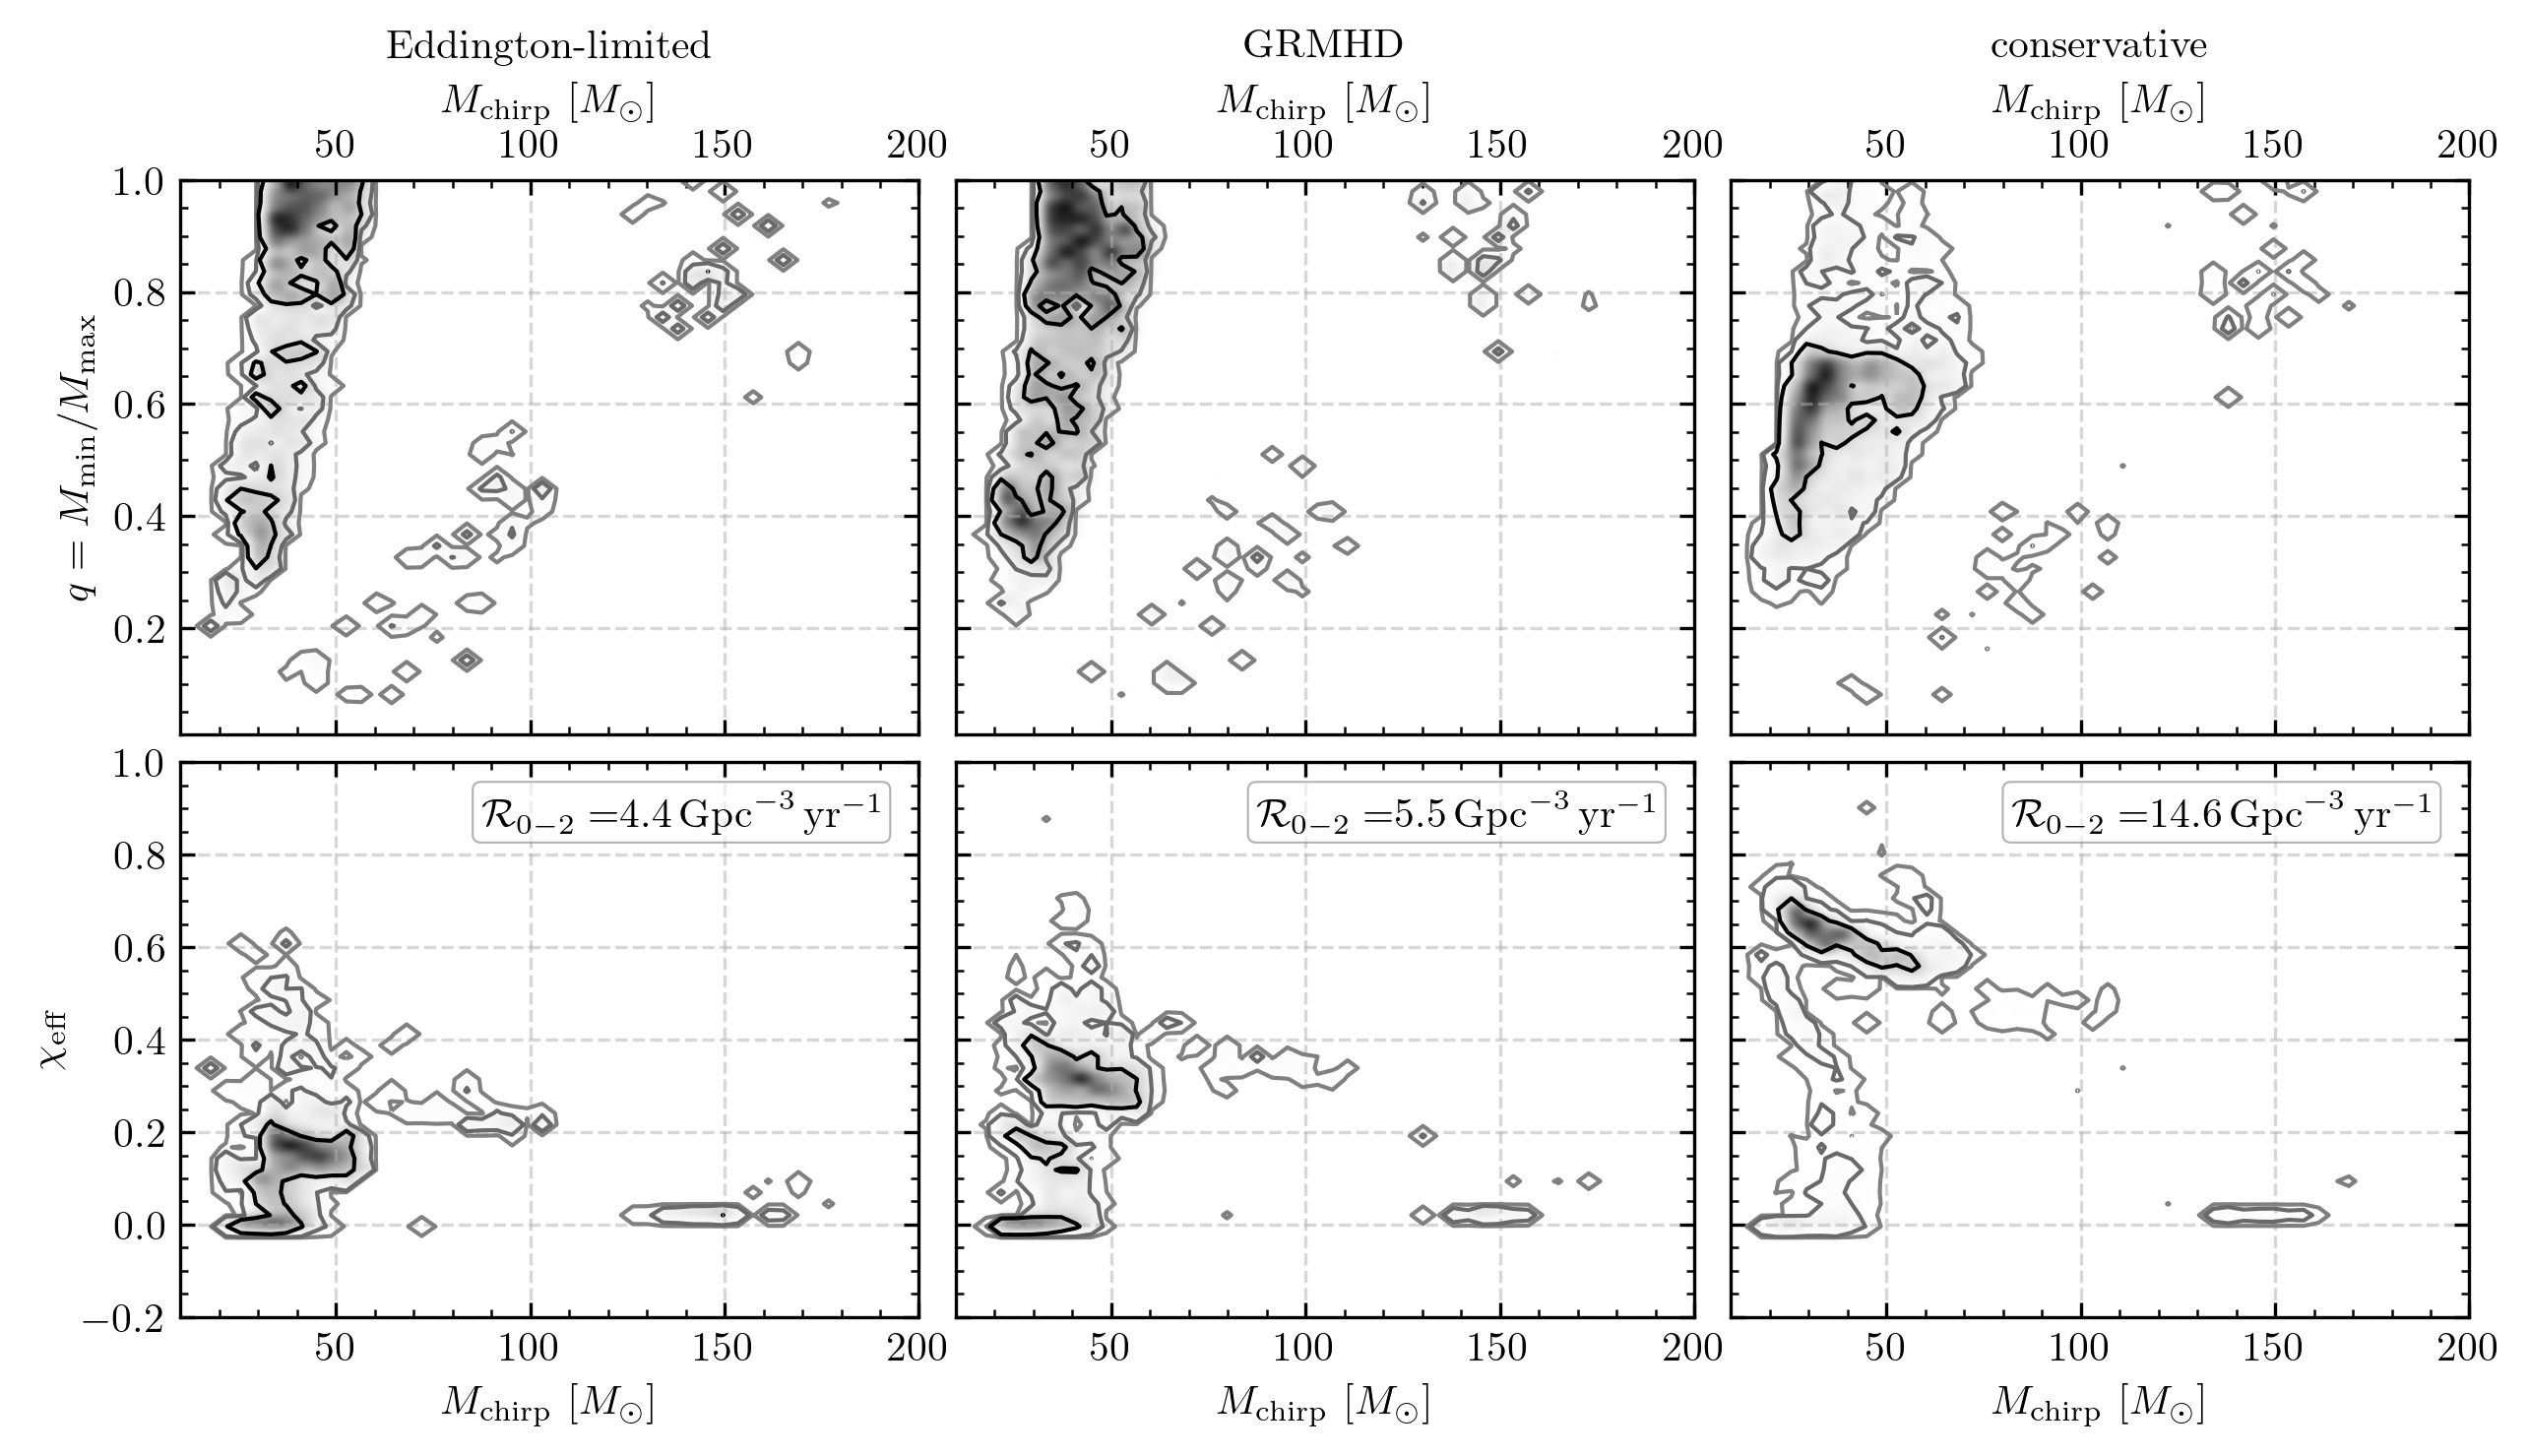

In [ ]:

# Define the data directory and folder types
data_dir = '/home/users/b/briel/scratch/high_mass_physics/data/main_figure/'
folder_types = ['Eddington-limited', 'GRMHD', 'conservative']

mass_bins = np.linspace(10, 200, 51)
q_bins = np.linspace(0, 1, 51)
chi_bins = np.linspace(-0.2, 1, 51)

fig, axes = plt.subplots(2, 3, figsize=(10, 5))
plt.subplots_adjust(wspace=0.05, hspace=0.05)

for i, folder_type in enumerate(folder_types):
    print(f"Processing folder: {folder_type}")
    folder_path = os.path.join(data_dir, folder_type)
    co_contact_file = os.path.join(folder_path, 'CO_contact.h5')
    data = Rates(co_contact_file, 'BBH', 'IllustrisTNG')
    print("Rates data loaded.")
    max_mass = np.maximum(data.population['S1_mass'].values, data.population['S2_mass'].values)
    mask = max_mass > 40
    z_max = 2
    z_event_mask = data.z_events <= z_max
    volume = get_shell_comoving_volume(0, z_max)
    weights = data.weights[z_event_mask][mask]
    filtered_population = data.population[mask]
    chirp_mass = filtered_population['chirp_mass'].to_numpy()
    mass_ratio = filtered_population['mass_ratio'].to_numpy()
    chi_eff = filtered_population['chi_eff'].to_numpy()
    
    

    # Top row: chirp mass vs mass ratio
    H0, xedges0, yedges0 = np.histogram2d(chirp_mass,
                                        mass_ratio,
                                        bins=(mass_bins, q_bins),
                                        weights=np.nansum(weights, axis=1)/volume)
    H0 /= np.diff(mass_bins)[:, None]  np.diff(q_bins)
    H0_sorted = np.sort(H0.flatten())[::-1]
    H0_cumsum = H0_sorted.cumsum()
    H0_total = H0_cumsum[-1]
    # Find contour levels for 1, 2, 3 sigma (containing 68.3%, 95.4%, 99.7% of the total)
    level0_1 = H0_sorted[np.searchsorted(H0_cumsum, 0.683 * H0_total)]
    level0_2 = H0_sorted[np.searchsorted(H0_cumsum, 0.954 * H0_total)]
    level0_3 = H0_sorted[np.searchsorted(H0_cumsum, 0.997 * H0_total)]
    levels0 = [level0_3, level0_2, level0_1]

    axes[0, i].imshow(H0.T, origin='lower', extent=[xedges0[0], xedges0[-1], yedges0[0], yedges0[-1]],
                        cmap='gray_r', aspect='auto', interpolation='gaussian')
    axes[0, i].contour(H0.T, levels=levels0, colors=['grey', 'dimgray', 'black'],
                    linewidths=[1.0, 1, 1],
                    extent=[xedges0[0], xedges0[-1], yedges0[0], yedges0[-1]])

    # Top bottom row: Chirp mass vs chi_eff
    H1, xedges1, yedges1 = np.histogram2d(chirp_mass,
                                            chi_eff,
                                            bins=(mass_bins, chi_bins),
                                            weights=np.nansum(weights, axis=1)/volume)
    H1 /= np.diff(mass_bins)[:, None] / np.diff(chi_bins)
    H1_sorted = np.sort(H1.flatten())[::-1]
    H1_cumsum = H1_sorted.cumsum()
    H1_total = H1_cumsum[-1]
    # Find contour levels for 1, 2, 3 sigma (containing 68.3%, 95.4%, 99.7% of the total)
    level1_1 = H1_sorted[np.searchsorted(H1_cumsum, 0.683 * H1_total)]
    level1_2 = H1_sorted[np.searchsorted(H1_cumsum, 0.954 * H1_total)]
    level1_3 = H1_sorted[np.searchsorted(H1_cumsum, 0.997 * H1_total)]
    levels1 = [level1_3, level1_2, level1_1]

    axes[1, i].imshow(H1.T, origin='lower', extent=[xedges1[0], xedges1[-1], yedges1[0], yedges1[-1]], 
                        cmap='gray_r', aspect='auto', interpolation='gaussian')

    axes[1, i].contour(H1.T, levels=levels1, colors=['grey', 'dimgray', 'black'],
                    linewidths=[1.0, 1, 1],
                    extent=[xedges1[0], xedges1[-1], yedges1[0], yedges1[-1]])

    # add rate denisty
    rate_density = np.nansum(weights)/volume
    axes[1, i].text(0.95, 0.95, r'$\mathcal{{R}}_{0{-}2}=$'+f'{rate_density:.1f}'+r'$\,\mathrm{{Gpc}}^{{-3}}\,\mathrm{{yr}}^{{-1}}$',
                    transform=axes[1, i].transAxes,
                    ha='right', va='top', 
                    bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.6, edgecolor='grey', lw=0.5))

# axes and stuff
axes[0,0].set_ylabel(r'$q=M_\mathrm{min}/M_\mathrm{max}$')
axes[1,0].set_ylabel(r'$\chi_\mathrm{eff}$')

for ax in axes[0,:]:
    ax.xaxis.set_label_position('top')
    ax.xaxis.tick_top()
    ax.xaxis.set_ticks_position('both')
    ax.set_ylim(1e-2,1)
    ax.set_title(folder_types[axes[0,:].tolist().index(ax)])
    
for ax in axes.flatten():
    ax.set_xlabel(r'$M_\mathrm{chirp}$ [$M_\odot$]')
    ax.set_xlim(10, 200)

for ax in axes[:,1:].flatten():
    ax.set_yticklabels([])
    
for ax in axes.flatten():
    ax.grid(ls='--', alpha=0.5)
    
output_dir = '/home/users/b/briel/scratch/high_mass_physics/figures'
plt.savefig(f'{output_dir}/main_figure.png', bbox_inches='tight')

# detectable population

In [1]:
from posydon.popsyn.transient_select_funcs import DCO_detectability

In [3]:
def DCO_wrapper(transient_chunk, z_events_chunk, weights_chunk):
    sensitivity = 'O4low_H1L1V1'
    return DCO_detectability(sensitivity, transient_chunk, z_events_chunk, weights_chunk, verbose=False)

In [5]:
data_dir = '/home/users/b/briel/scratch/high_mass_physics/data/figure_2/'
folder_types = ['no_kick', 'low_kick', 'normal_kick']
for folder_type in folder_types:
    folder_path = os.path.join(data_dir, folder_type)
    co_contact_file = os.path.join(folder_path, 'CO_contact.h5')
    data = Rates(co_contact_file, 'BBH', 'IllustrisTNG')
    data.calculate_observable_population(DCO_wrapper, 'O4low_H1L1V1')

Missing ini parameter: metallicity
Missing ini parameter: orbital_separation_scheme
Missing ini parameter: orbital_separation_min
Missing ini parameter: orbital_separation_max
Missing ini parameter: metallicity
Missing ini parameter: orbital_separation_scheme
Missing ini parameter: orbital_separation_min
Missing ini parameter: orbital_separation_max
Missing ini parameter: metallicity
Missing ini parameter: orbital_separation_scheme
Missing ini parameter: orbital_separation_min
Missing ini parameter: orbital_separation_max


Processing folder: Eddington-limited
Missing ini parameter: metallicity
Missing ini parameter: orbital_separation_scheme
Missing ini parameter: orbital_separation_min
Missing ini parameter: orbital_separation_max
Rates data loaded.
Processing folder: GRMHD
Missing ini parameter: metallicity
Missing ini parameter: orbital_separation_scheme
Missing ini parameter: orbital_separation_min
Missing ini parameter: orbital_separation_max
Rates data loaded.
Processing folder: conservative
Missing ini parameter: metallicity
Missing ini parameter: orbital_separation_scheme
Missing ini parameter: orbital_separation_min
Missing ini parameter: orbital_separation_max
Rates data loaded.


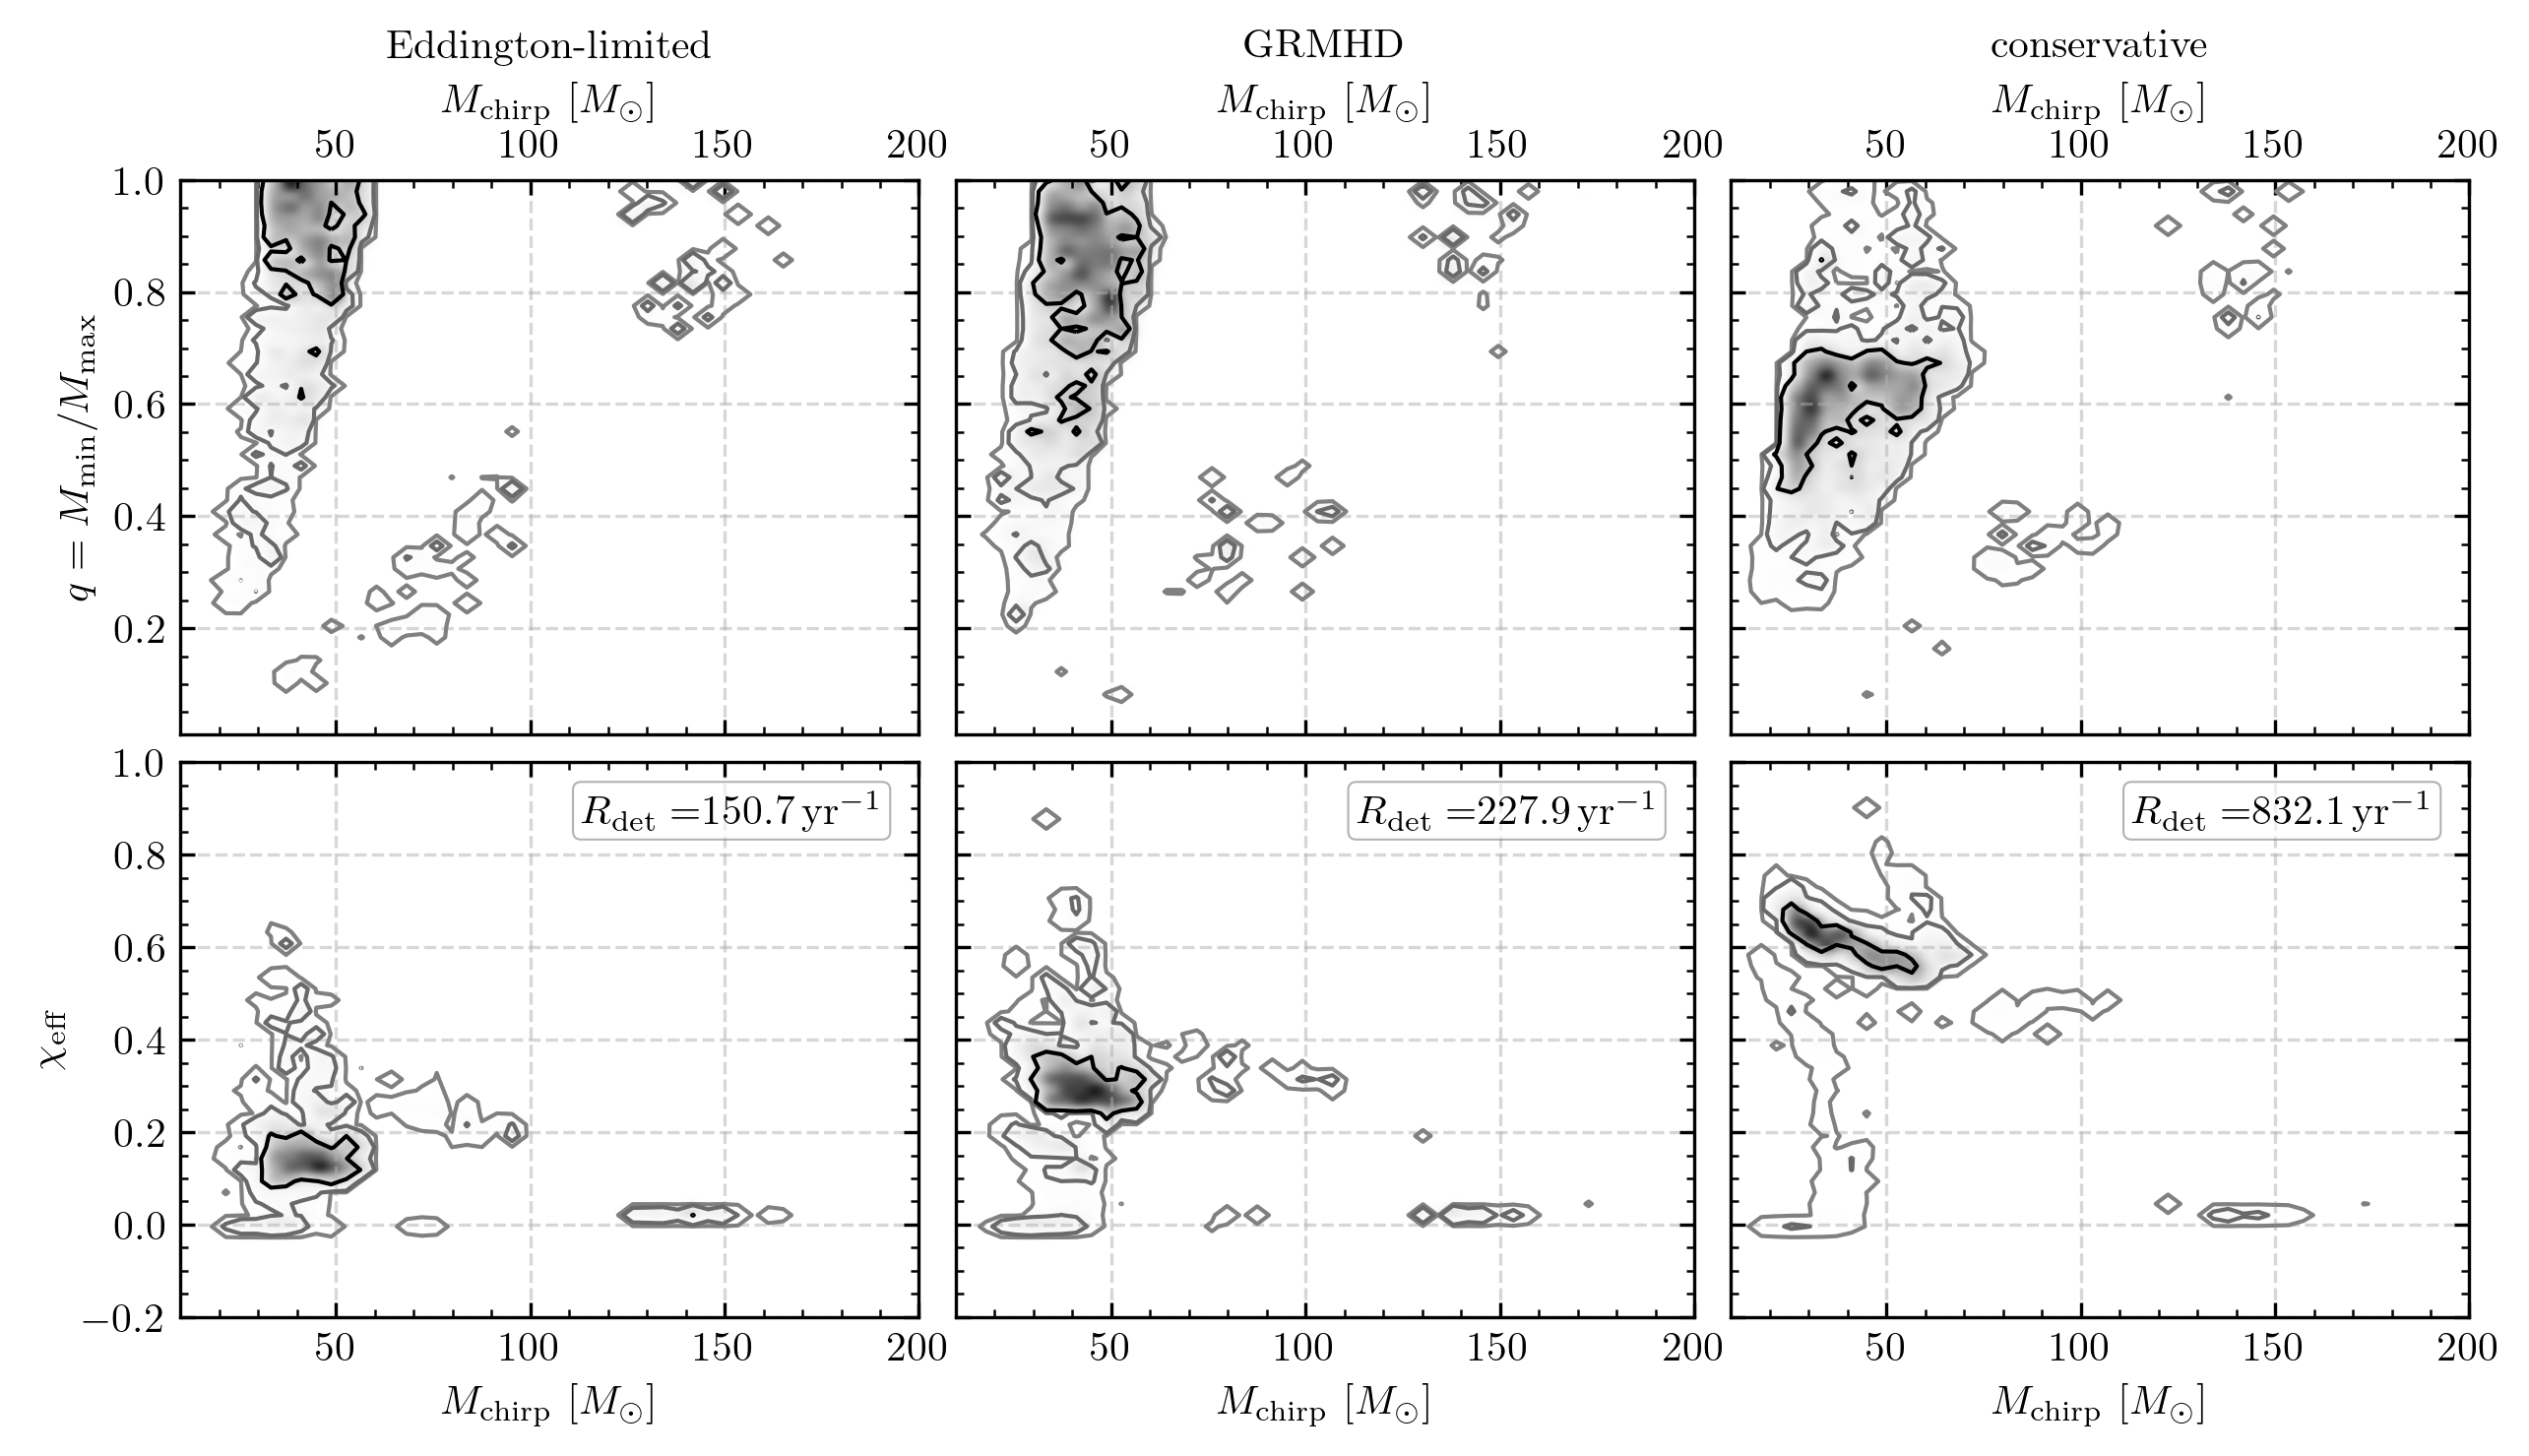

In [181]:

# Define the data directory and folder types
data_dir = '/home/users/b/briel/scratch/high_mass_physics/data/main_figure/'
folder_types = ['Eddington-limited', 'GRMHD', 'conservative']

mass_bins = np.linspace(10, 200, 51)
q_bins = np.linspace(0, 1, 51)
chi_bins = np.linspace(-0.2, 1, 51)

fig, axes = plt.subplots(2, 3, figsize=(10, 5))
plt.subplots_adjust(wspace=0.05, hspace=0.05)

for i, folder_type in enumerate(folder_types):
    print(f"Processing folder: {folder_type}")
    folder_path = os.path.join(data_dir, folder_type)
    co_contact_file = os.path.join(folder_path, 'CO_contact.h5')
    data = Rates(co_contact_file, 'BBH', 'IllustrisTNG')
    print("Rates data loaded.")
    max_mass = np.maximum(data.population['S1_mass'].values, data.population['S2_mass'].values)
    mask = max_mass > 40
    weights = data.observable_population('O4low_H1L1V1')[mask]
    filtered_population = data.population[mask]
    chirp_mass = filtered_population['chirp_mass'].to_numpy()
    mass_ratio = filtered_population['mass_ratio'].to_numpy()
    chi_eff = filtered_population['chi_eff'].to_numpy()
    
    # Top row: chirp mass vs mass ratio
    H0, xedges0, yedges0 = np.histogram2d(chirp_mass,
                                        mass_ratio,
                                        bins=(mass_bins, q_bins),
                                        weights=np.nansum(weights, axis=1))
    H0 /= np.diff(mass_bins)[:, None] / np.diff(q_bins)
    H0_sorted = np.sort(H0.flatten())[::-1]
    H0_cumsum = H0_sorted.cumsum()
    H0_total = H0_cumsum[-1]
    # Find contour levels for 1, 2, 3 sigma (containing 68.3%, 95.4%, 99.7% of the total)
    level0_1 = H0_sorted[np.searchsorted(H0_cumsum, 0.683 * H0_total)]
    level0_2 = H0_sorted[np.searchsorted(H0_cumsum, 0.954 * H0_total)]
    level0_3 = H0_sorted[np.searchsorted(H0_cumsum, 0.997 * H0_total)]
    levels0 = [level0_3, level0_2, level0_1]

    axes[0, i].imshow(H0.T, origin='lower', extent=[xedges0[0], xedges0[-1], yedges0[0], yedges0[-1]],
                        cmap='gray_r', aspect='auto', interpolation='gaussian')
    axes[0, i].contour(H0.T, levels=levels0, colors=['grey', 'dimgray', 'black'],
                    linewidths=[1.0, 1, 1],
                    extent=[xedges0[0], xedges0[-1], yedges0[0], yedges0[-1]])

    # Top bottom row: Chirp mass vs chi_eff
    H1, xedges1, yedges1 = np.histogram2d(chirp_mass,
                                            chi_eff,
                                            bins=(mass_bins, chi_bins),
                                            weights=np.nansum(weights, axis=1))
    H1 /= np.diff(mass_bins)[:, None] / np.diff(chi_bins)
    H1_sorted = np.sort(H1.flatten())[::-1]
    H1_cumsum = H1_sorted.cumsum()
    H1_total = H1_cumsum[-1]
    # Find contour levels for 1, 2, 3 sigma (containing 68.3%, 95.4%, 99.7% of the total)
    level1_1 = H1_sorted[np.searchsorted(H1_cumsum, 0.683 * H1_total)]
    level1_2 = H1_sorted[np.searchsorted(H1_cumsum, 0.954 * H1_total)]
    level1_3 = H1_sorted[np.searchsorted(H1_cumsum, 0.997 * H1_total)]
    levels1 = [level1_3, level1_2, level1_1]

    axes[1, i].imshow(H1.T, origin='lower', extent=[xedges1[0], xedges1[-1], yedges1[0], yedges1[-1]], 
                        cmap='gray_r', aspect='auto', interpolation='gaussian')

    axes[1, i].contour(H1.T, levels=levels1, colors=['grey', 'dimgray', 'black'],
                    linewidths=[1.0, 1, 1],
                    extent=[xedges1[0], xedges1[-1], yedges1[0], yedges1[-1]])

    # add rate
    rate_density = np.nansum(weights)
    axes[1, i].text(0.95, 0.95, r'$R_\mathrm{det}=$'+f'{rate_density:.1f}'+r'$\,\mathrm{{yr}}^{{-1}}$',
                    transform=axes[1, i].transAxes,
                    ha='right', va='top', 
                    bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.6, edgecolor='grey', lw=0.5))

# axes and stuff
axes[0,0].set_ylabel(r'$q=M_\mathrm{min}/M_\mathrm{max}$')
axes[1,0].set_ylabel(r'$\chi_\mathrm{eff}$')

for ax in axes[0,:]:
    ax.xaxis.set_label_position('top')
    ax.xaxis.tick_top()
    ax.xaxis.set_ticks_position('both')
    ax.set_ylim(1e-2,1)
    ax.set_title(folder_types[axes[0,:].tolist().index(ax)])
    
for ax in axes.flatten():
    ax.set_xlabel(r'$M_\mathrm{chirp}$ [$M_\odot$]')
    ax.set_xlim(10, 200)

for ax in axes[:,1:].flatten():
    ax.set_yticklabels([])
    
for ax in axes.flatten():
    ax.grid(ls='--', alpha=0.5)
    
output_dir = '/home/users/b/briel/scratch/high_mass_physics/figures'
plt.savefig(f'{output_dir}/main_figure_detectable.png', bbox_inches='tight')

In [162]:
data_dir = '/home/users/b/briel/scratch/high_mass_physics/data/figure_2/'
folder_types = ['no_kick', 'low_kick', 'normal_kick']

Processing folder: no_kick
Missing ini parameter: metallicity
Missing ini parameter: orbital_separation_scheme
Missing ini parameter: orbital_separation_min
Missing ini parameter: orbital_separation_max
Rates data loaded.
Processing folder: low_kick
Missing ini parameter: metallicity
Missing ini parameter: orbital_separation_scheme
Missing ini parameter: orbital_separation_min
Missing ini parameter: orbital_separation_max
Rates data loaded.
Processing folder: normal_kick
Missing ini parameter: metallicity
Missing ini parameter: orbital_separation_scheme
Missing ini parameter: orbital_separation_min
Missing ini parameter: orbital_separation_max
Rates data loaded.


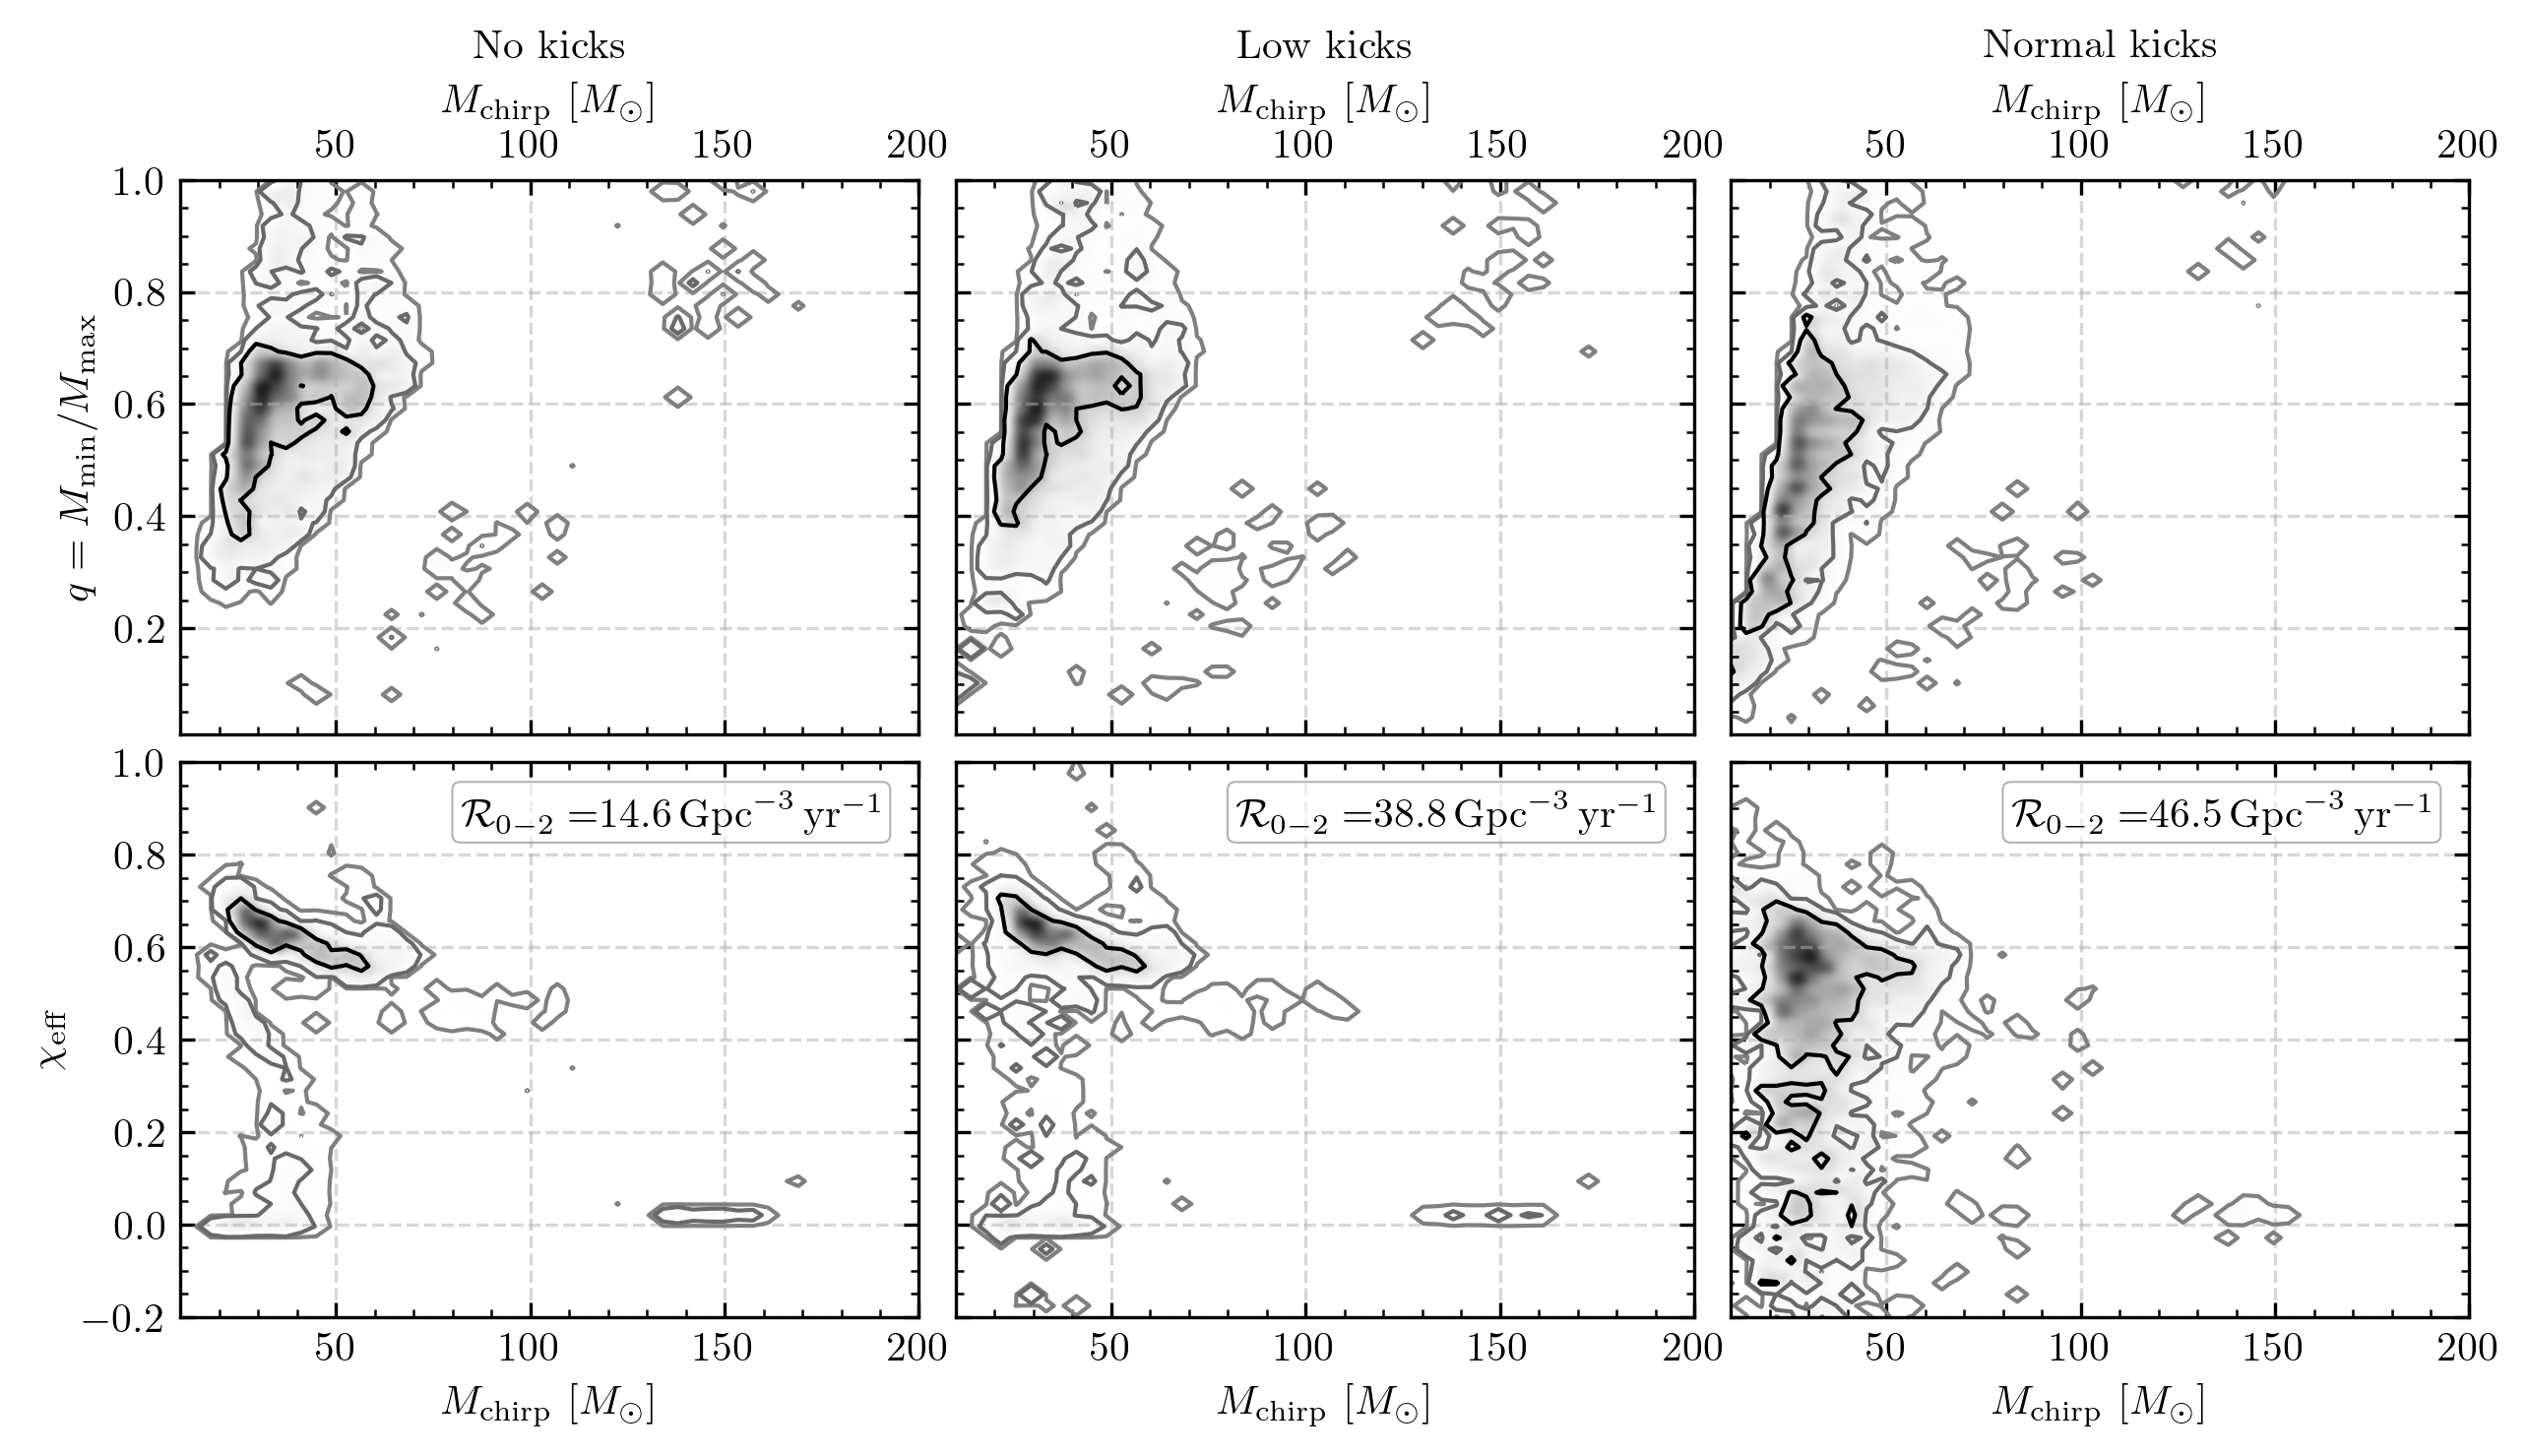

In [165]:
mass_bins = np.linspace(10, 200, 51)
q_bins = np.linspace(0, 1, 51)
chi_bins = np.linspace(-0.2, 1, 51)

fig, axes = plt.subplots(2, 3, figsize=(10, 5))
plt.subplots_adjust(wspace=0.05, hspace=0.05)

for i, folder_type in enumerate(folder_types):
    print(f"Processing folder: {folder_type}")
    folder_path = os.path.join(data_dir, folder_type)
    co_contact_file = os.path.join(folder_path, 'CO_contact.h5')
    data = Rates(co_contact_file, 'BBH', 'IllustrisTNG')
    print("Rates data loaded.")
    max_mass = np.maximum(data.population['S1_mass'].values, data.population['S2_mass'].values)
    mask = max_mass > 40
    z_max = 2
    z_event_mask = data.z_events <= z_max
    volume = get_shell_comoving_volume(0, z_max)
    weights = data.weights[z_event_mask][mask]
    filtered_population = data.population[mask]
    chirp_mass = filtered_population['chirp_mass'].to_numpy()
    mass_ratio = filtered_population['mass_ratio'].to_numpy()
    chi_eff = filtered_population['chi_eff'].to_numpy()
    
    

    # Top row: chirp mass vs mass ratio
    H0, xedges0, yedges0 = np.histogram2d(chirp_mass,
                                        mass_ratio,
                                        bins=(mass_bins, q_bins),
                                        weights=np.nansum(weights, axis=1)/volume)
    H0 /= np.diff(mass_bins)[:, None] / np.diff(q_bins)
    H0_sorted = np.sort(H0.flatten())[::-1]
    H0_cumsum = H0_sorted.cumsum()
    H0_total = H0_cumsum[-1]
    # Find contour levels for 1, 2, 3 sigma (containing 68.3%, 95.4%, 99.7% of the total)
    level0_1 = H0_sorted[np.searchsorted(H0_cumsum, 0.683 * H0_total)]
    level0_2 = H0_sorted[np.searchsorted(H0_cumsum, 0.954 * H0_total)]
    level0_3 = H0_sorted[np.searchsorted(H0_cumsum, 0.997 * H0_total)]
    levels0 = [level0_3, level0_2, level0_1]

    axes[0, i].imshow(H0.T, origin='lower', extent=[xedges0[0], xedges0[-1], yedges0[0], yedges0[-1]],
                        cmap='gray_r', aspect='auto', interpolation='gaussian')
    axes[0, i].contour(H0.T, levels=levels0, colors=['grey', 'dimgray', 'black'],
                    linewidths=[1.0, 1, 1],
                    extent=[xedges0[0], xedges0[-1], yedges0[0], yedges0[-1]])

    # Top bottom row: Chirp mass vs chi_eff
    H1, xedges1, yedges1 = np.histogram2d(chirp_mass,
                                            chi_eff,
                                            bins=(mass_bins, chi_bins),
                                            weights=np.nansum(weights, axis=1)/volume)
    H1 /= np.diff(mass_bins)[:, None] / np.diff(chi_bins)
    H1_sorted = np.sort(H1.flatten())[::-1]
    H1_cumsum = H1_sorted.cumsum()
    H1_total = H1_cumsum[-1]
    # Find contour levels for 1, 2, 3 sigma (containing 68.3%, 95.4%, 99.7% of the total)
    level1_1 = H1_sorted[np.searchsorted(H1_cumsum, 0.683 * H1_total)]
    level1_2 = H1_sorted[np.searchsorted(H1_cumsum, 0.954 * H1_total)]
    level1_3 = H1_sorted[np.searchsorted(H1_cumsum, 0.997 * H1_total)]
    levels1 = [level1_3, level1_2, level1_1]

    axes[1, i].imshow(H1.T, origin='lower', extent=[xedges1[0], xedges1[-1], yedges1[0], yedges1[-1]], 
                        cmap='gray_r', aspect='auto', interpolation='gaussian')

    axes[1, i].contour(H1.T, levels=levels1, colors=['grey', 'dimgray', 'black'],
                    linewidths=[1.0, 1, 1],
                    extent=[xedges1[0], xedges1[-1], yedges1[0], yedges1[-1]])

    # add rate denisty
    rate_density = np.nansum(weights)/volume
    axes[1, i].text(0.95, 0.95, r'$\mathcal{{R}}_{0{-}2}=$'+f'{rate_density:.1f}'+r'$\,\mathrm{{Gpc}}^{{-3}}\,\mathrm{{yr}}^{{-1}}$',
                    transform=axes[1, i].transAxes,
                    ha='right', va='top', 
                    bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.6, edgecolor='grey', lw=0.5))

# axes and stuff
axes[0,0].set_ylabel(r'$q=M_\mathrm{min}/M_\mathrm{max}$')
axes[1,0].set_ylabel(r'$\chi_\mathrm{eff}$')


title_mapping = {
    'no_kick': 'No kicks',
    'low_kick': 'Low kicks',
    'normal_kick': 'Normal kicks'
}

for ax in axes[0,:]:
    ax.xaxis.set_label_position('top')
    ax.xaxis.tick_top()
    ax.xaxis.set_ticks_position('both')
    ax.set_ylim(1e-2,1)
    ax.set_title(title_mapping[folder_types[axes[0,:].tolist().index(ax)]])
    
for ax in axes.flatten():
    ax.set_xlabel(r'$M_\mathrm{chirp}$ [$M_\odot$]')
    ax.set_xlim(10, 200)

for ax in axes[:,1:].flatten():
    ax.set_yticklabels([])
    
for ax in axes.flatten():
    ax.grid(ls='--', alpha=0.5)
    
output_dir = '/home/users/b/briel/scratch/high_mass_physics/figures'
plt.savefig(f'{output_dir}/figure_2_kicks.png', bbox_inches='tight')

In [130]:
from popsummary.popresult import PopulationResult

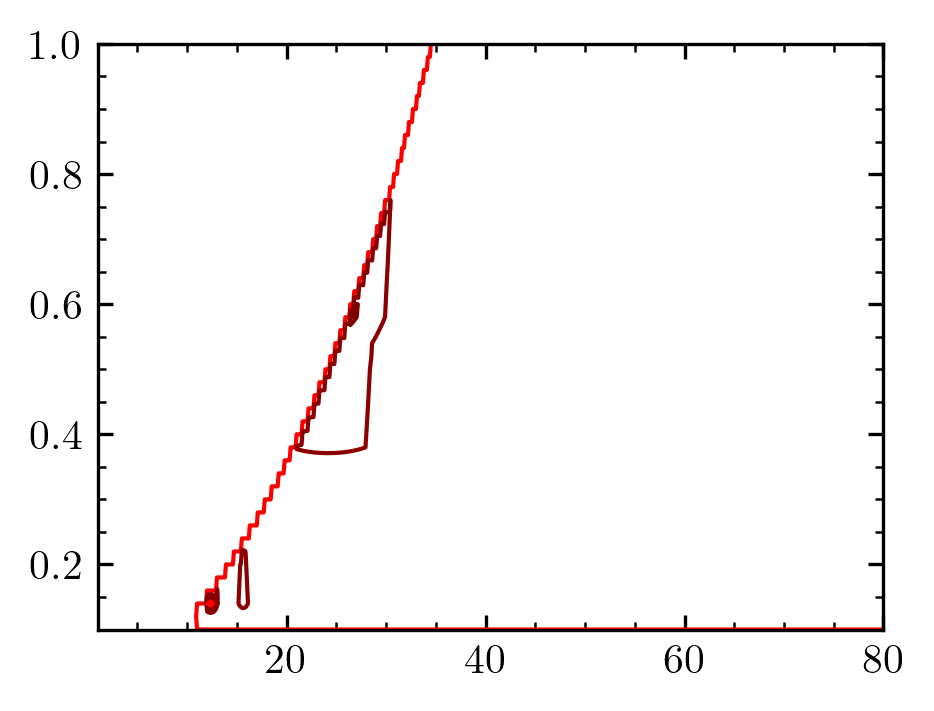

In [ ]:

bspline_file = '/home/users/b/briel/scratch/high_mass_physics/data/GWTC-4_analysis_BBH/BBHMass_FlexibleMixtures.h5'
obs_data = PopulationResult(bspline_file)
m1, m1_pdf = obs_data.get_rates_on_grids('chirp_mass')
chirp = m1[0]
chirp_pdf = m1_pdf[1]
q, q_pdf = obs_data.get_rates_on_grids('mass_ratio')
q=q[0]
q_pdf = q_pdf[1]

H_obs = np.zeros((len(chirp), len(q)))
for i in range(len(chirp)):
    for j in range(len(q)):
        m1_tmp = (chirp[i] * (1 + q[j])**(1/5)) / (q[j]**(3/5))
        if m1_tmp > 40:
            H_obs[i,j] = chirp_pdf[i] * q_pdf[j]
        else:
            H_obs[i,j] = 0

H_obs_sorted = np.sort(H_obs.flatten())[::-1]
H_obs_cumsum = H_obs_sorted.cumsum()
H_obs_total = H_obs_cumsum[-1]


# Find contour levels for 1, 2, 3 sigma (containing 68.3%, 95.4%, 99.7% of the total)
plt.contour(H_obs.T, levels=3, colors=['red', 'darkred', 'maroon'],
                linewidths=[1.0, 1, 1],
                extent=[chirp[0], chirp[-1], q[0], q[-1]])


In [148]:
import h5py

bs_o4 = h5py.File('/home/users/b/briel/scratch/high_mass_physics/data/GWTC-4_analysis_BBH/BBHMass_FlexibleMixtures.h5', 'r')

In [150]:
bs_o4['posterior/rates_on_grids'].keys()

<KeysViewHDF5 ['aligned_spin', 'chirp_mass', 'chirp_mass_aligned_spin_joint', 'chirp_mass_mass_ratio_joint', 'component_mass', 'mass_ratio', 'mass_ratio_aligned_spin_joint', 'primary_mass', 'rate_z_evol', 'secondary_mass']>